# Lab 1 - Convolutional Neural Network (CNN)
- **a.** Sử dụng mô hình CNN cho bài toán phân loại ảnh (dataset MNIST)
- **b.** Sử dụng mô hình CNN phân loại tập CIFAR-10
- **c.** Visualize các tham số, số lượng layer, số lượng tham số huấn luyện

## Cài đặt & Import thư viện

In [19]:
import sys
print(f"Python version: {sys.version}")
print("Note: Python 3.14 is not yet supported by TensorFlow.")
print("Installing PyTorch-based alternatives instead...")

%pip install torch torchvision matplotlib numpy pandas -q

Python version: 3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]
Note: Python 3.14 is not yet supported by TensorFlow.
Installing PyTorch-based alternatives instead...
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST, CIFAR10
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

PyTorch version: 2.10.0+cpu
CUDA available: False
Device: cpu


---
## Phần A: CNN phân loại ảnh dataset MNIST
### 1. Load và tiền xử lý dữ liệu MNIST

In [21]:
# Load MNIST dataset using PyTorch
transform = transforms.Compose([transforms.ToTensor()])

mnist_train = MNIST(root='./data', train=True, transform=transform, download=True)
mnist_test = MNIST(root='./data', train=False, transform=transform, download=True)

x_train_mnist = mnist_train.data.unsqueeze(1).float() / 255.0
y_train_mnist = mnist_train.targets
x_test_mnist = mnist_test.data.unsqueeze(1).float() / 255.0
y_test_mnist = mnist_test.targets

# Convert labels to one-hot encoding for compatibility
y_train_mnist_cat = torch.nn.functional.one_hot(y_train_mnist, 10).float()
y_test_mnist_cat = torch.nn.functional.one_hot(y_test_mnist, 10).float()

print(f"Training shape: {x_train_mnist.shape}")
print(f"Test shape:     {x_test_mnist.shape}")
print(f"Labels:         0-9 ({len(torch.unique(y_train_mnist))} classes)")

Training shape: torch.Size([60000, 1, 28, 28])
Test shape:     torch.Size([10000, 1, 28, 28])
Labels:         0-9 (10 classes)


### 2. Hiển thị ảnh mẫu MNIST

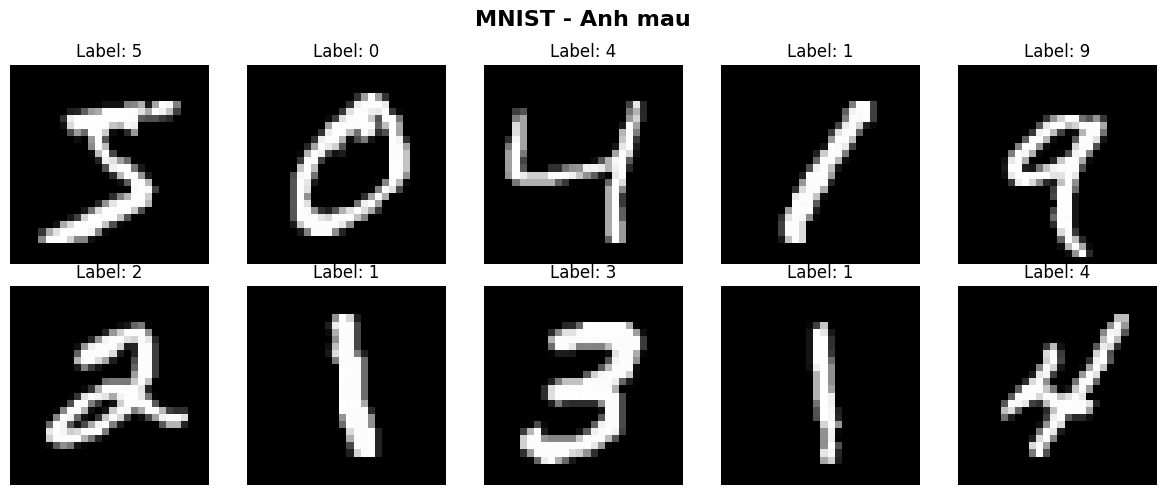

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_mnist[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {y_train_mnist[i]}", fontsize=12)
    ax.axis('off')
plt.suptitle("MNIST - Anh mau", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Xây dựng mô hình CNN cho MNIST

In [23]:
# Define MNIST CNN model using PyTorch
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

mnist_model = MNISTNet().to(device)
optimizer_mnist = optim.Adam(mnist_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Print model summary
total_params = sum(p.numel() for p in mnist_model.parameters())
trainable_params = sum(p.numel() for p in mnist_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel Architecture:")
print(mnist_model)

Total parameters: 458,890
Trainable parameters: 458,890

Model Architecture:
MNISTNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### 4. Huấn luyện mô hình MNIST

In [24]:
# Training MNIST model
train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
val_size = int(0.1 * len(mnist_train))
train_size = len(mnist_train) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(mnist_train, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

epochs = 10
history_mnist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    # Training
    mnist_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_mnist.zero_grad()
        outputs = mnist_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_mnist.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    # Validation
    mnist_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mnist_model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    
    history_mnist['train_loss'].append(train_loss)
    history_mnist['train_acc'].append(train_acc)
    history_mnist['val_loss'].append(val_loss)
    history_mnist['val_acc'].append(val_acc)
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch [2/10] - Train Loss: 0.0665, Train Acc: 0.9801, Val Loss: 0.0384, Val Acc: 0.9887
Epoch [4/10] - Train Loss: 0.0437, Train Acc: 0.9872, Val Loss: 0.0404, Val Acc: 0.9860
Epoch [6/10] - Train Loss: 0.0307, Train Acc: 0.9905, Val Loss: 0.0356, Val Acc: 0.9903
Epoch [8/10] - Train Loss: 0.0242, Train Acc: 0.9926, Val Loss: 0.0338, Val Acc: 0.9905
Epoch [10/10] - Train Loss: 0.0203, Train Acc: 0.9930, Val Loss: 0.0334, Val Acc: 0.9918


### 5. Đánh giá mô hình MNIST

In [25]:
# Evaluate MNIST model
mnist_model.eval()
test_loader = DataLoader(mnist_test, batch_size=128, shuffle=False)
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mnist_model(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_loss /= len(test_loader)
test_acc = test_correct / test_total

print(f"{'='*40}")
print(f"MNIST - Test Loss:     {test_loss:.4f}")
print(f"MNIST - Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"{'='*40}")

MNIST - Test Loss:     0.0289
MNIST - Test Accuracy: 0.9917 (99.17%)


### 6. Biểu đồ huấn luyện MNIST

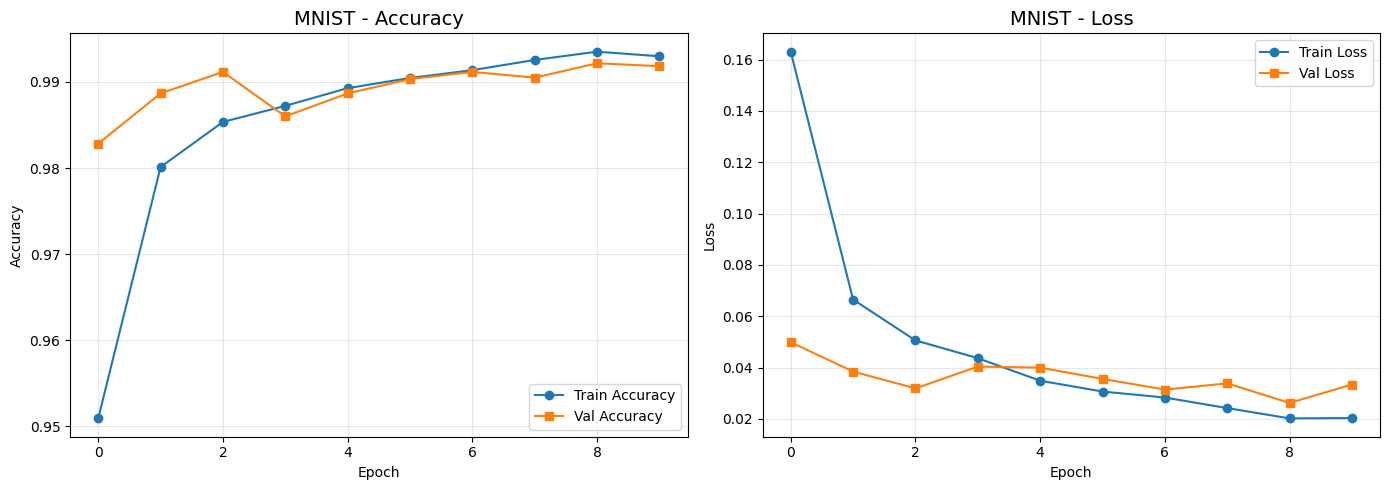

In [26]:
# Plot MNIST training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_mnist['train_acc'], label='Train Accuracy', marker='o')
ax1.plot(history_mnist['val_acc'], label='Val Accuracy', marker='s')
ax1.set_title('MNIST - Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_mnist['train_loss'], label='Train Loss', marker='o')
ax2.plot(history_mnist['val_loss'], label='Val Loss', marker='s')
ax2.set_title('MNIST - Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Phần B: CNN phân loại tập CIFAR-10
### 1. Load và tiền xử lý dữ liệu CIFAR-10

In [27]:
# Load CIFAR-10 dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

transform = transforms.Compose([transforms.ToTensor()])

cifar_train = CIFAR10(root='./data', train=True, transform=transform, download=True)
cifar_test = CIFAR10(root='./data', train=False, transform=transform, download=True)

x_train_cifar = cifar_train.data.transpose(0, 3, 1, 2).astype('float32') / 255.0
y_train_cifar = np.array(cifar_train.targets)
x_test_cifar = cifar_test.data.transpose(0, 3, 1, 2).astype('float32') / 255.0
y_test_cifar = np.array(cifar_test.targets)

print(f"Training shape: {x_train_cifar.shape}")
print(f"Test shape:     {x_test_cifar.shape}")
print(f"Classes:        {class_names}")

100.0%
c:\Users\ASUS\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training shape: (50000, 3, 32, 32)
Test shape:     (10000, 3, 32, 32)
Classes:        ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 2. Hiển thị ảnh mẫu CIFAR-10

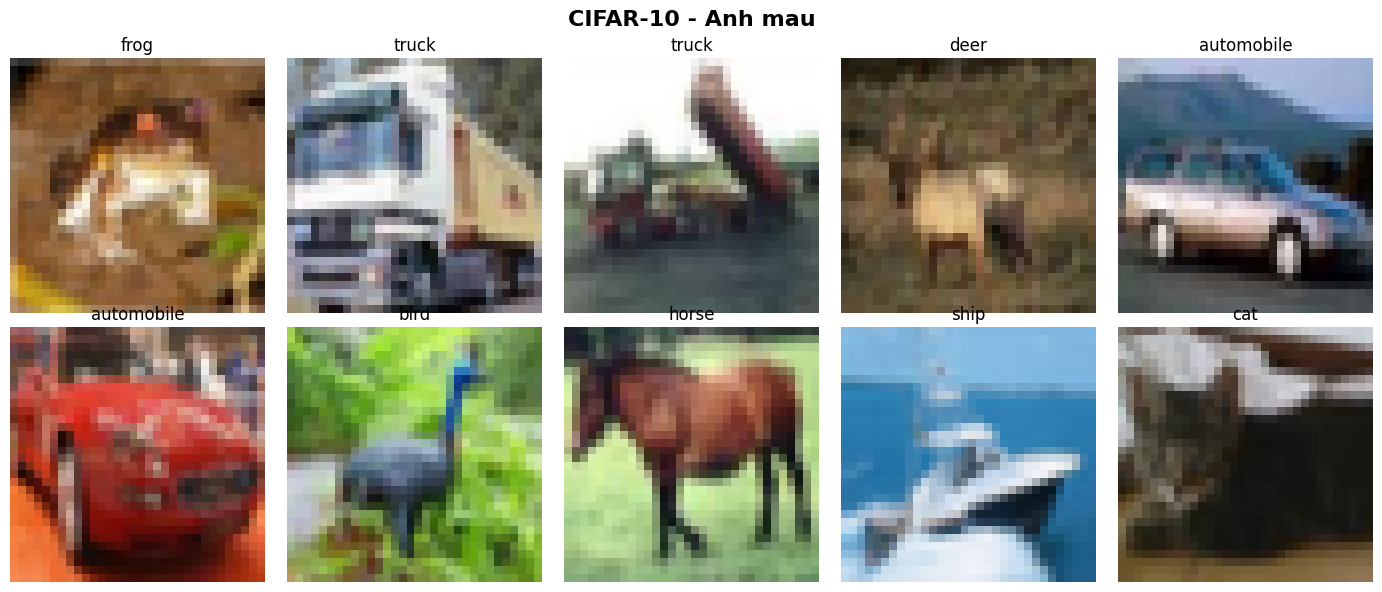

In [28]:
# Display CIFAR-10 sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = x_train_cifar[i].transpose(1, 2, 0)
    ax.imshow(img)
    ax.set_title(class_names[y_train_cifar[i]], fontsize=12)
    ax.axis('off')
plt.suptitle("CIFAR-10 - Anh mau", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Xây dựng mô hình CNN cho CIFAR-10

In [31]:
# Define CIFAR-10 CNN model using PyTorch
class CIFAR10Net(nn.Module):
    def __init__(self):
        super(CIFAR10Net, self).__init__()
        
        # Convolutional blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.25)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)
        
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout(0.25)
        
        self.flatten = nn.Flatten()
        # After 3 pooling layers on 32x32 image: 32 -> 16 -> 8 -> 4, so 128*4*4 = 2048
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.bn7 = nn.BatchNorm1d(256)
        self.drop4 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)
    
    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool1(torch.relu(self.bn2(self.conv2(x))))
        x = self.drop1(x)
        
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool2(torch.relu(self.bn4(self.conv4(x))))
        x = self.drop2(x)
        
        x = torch.relu(self.bn5(self.conv5(x)))
        x = self.pool3(torch.relu(self.bn6(self.conv6(x))))
        x = self.drop3(x)
        
        x = self.flatten(x)
        x = torch.relu(self.bn7(self.fc1(x)))
        x = self.drop4(x)
        x = self.fc2(x)
        
        return x

# Add data augmentation to transforms
augment_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
])

cifar_model = CIFAR10Net().to(device)
optimizer_cifar = optim.Adam(cifar_model.parameters(), lr=0.001)

# Print model summary
total_params_cifar = sum(p.numel() for p in cifar_model.parameters())
trainable_params_cifar = sum(p.numel() for p in cifar_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params_cifar:,}")
print(f"Trainable parameters: {trainable_params_cifar:,}")
print(f"\nModel Architecture:")
print(cifar_model)

Total parameters: 815,530
Trainable parameters: 815,530

Model Architecture:
CIFAR10Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace

### 4. Huấn luyện mô hình CIFAR-10

In [32]:
# Training CIFAR-10 model
cifar_train_tensor = torch.from_numpy(x_train_cifar).float()
cifar_train_labels = torch.from_numpy(y_train_cifar).long()
cifar_dataset = torch.utils.data.TensorDataset(cifar_train_tensor, cifar_train_labels)

train_size = int(0.9 * len(cifar_dataset))
val_size = len(cifar_dataset) - train_size
train_dataset_cifar, val_dataset_cifar = torch.utils.data.random_split(cifar_dataset, [train_size, val_size])
train_loader_cifar = DataLoader(train_dataset_cifar, batch_size=64, shuffle=True)
val_loader_cifar = DataLoader(val_dataset_cifar, batch_size=64, shuffle=False)

epochs_cifar = 30
history_cifar = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs_cifar):
    # Training
    cifar_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader_cifar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_cifar.zero_grad()
        outputs = cifar_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_cifar.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    # Validation
    cifar_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader_cifar:
            images, labels = images.to(device), labels.to(device)
            outputs = cifar_model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    train_loss /= len(train_loader_cifar)
    train_acc = train_correct / train_total
    val_loss /= len(val_loader_cifar)
    val_acc = val_correct / val_total
    
    history_cifar['train_loss'].append(train_loss)
    history_cifar['train_acc'].append(train_acc)
    history_cifar['val_loss'].append(val_loss)
    history_cifar['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs_cifar}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch [5/30] - Train Loss: 0.6394, Train Acc: 0.7781, Val Loss: 0.6843, Val Acc: 0.7634
Epoch [10/30] - Train Loss: 0.4568, Train Acc: 0.8412, Val Loss: 0.4664, Val Acc: 0.8384
Epoch [15/30] - Train Loss: 0.3521, Train Acc: 0.8774, Val Loss: 0.5068, Val Acc: 0.8372
Epoch [20/30] - Train Loss: 0.2941, Train Acc: 0.8961, Val Loss: 0.4494, Val Acc: 0.8562
Epoch [25/30] - Train Loss: 0.2421, Train Acc: 0.9150, Val Loss: 0.4606, Val Acc: 0.8650
Epoch [30/30] - Train Loss: 0.2180, Train Acc: 0.9218, Val Loss: 0.4600, Val Acc: 0.8692


### 5. Đánh giá mô hình CIFAR-10

In [33]:
# Evaluate CIFAR-10 model
cifar_model.eval()
cifar_test_tensor = torch.from_numpy(x_test_cifar).float()
cifar_test_labels = torch.from_numpy(y_test_cifar).long()
test_loader_cifar = DataLoader(torch.utils.data.TensorDataset(cifar_test_tensor, cifar_test_labels), 
                               batch_size=64, shuffle=False)

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader_cifar:
        images, labels = images.to(device), labels.to(device)
        outputs = cifar_model(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_loss /= len(test_loader_cifar)
test_acc = test_correct / test_total

print(f"{'='*40}")
print(f"CIFAR-10 - Test Loss:     {test_loss:.4f}")
print(f"CIFAR-10 - Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"{'='*40}")

CIFAR-10 - Test Loss:     0.4667
CIFAR-10 - Test Accuracy: 0.8633 (86.33%)


### 6. Biểu đồ huấn luyện CIFAR-10

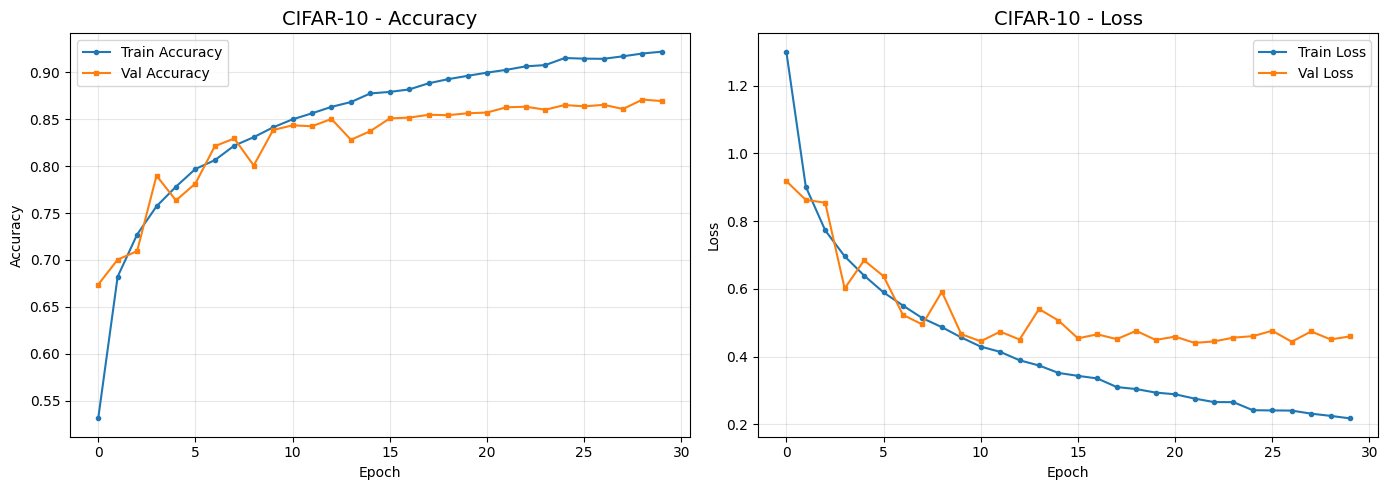

In [34]:
# Plot CIFAR-10 training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_cifar['train_acc'], label='Train Accuracy', marker='o', markersize=3)
ax1.plot(history_cifar['val_acc'], label='Val Accuracy', marker='s', markersize=3)
ax1.set_title('CIFAR-10 - Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_cifar['train_loss'], label='Train Loss', marker='o', markersize=3)
ax2.plot(history_cifar['val_loss'], label='Val Loss', marker='s', markersize=3)
ax2.set_title('CIFAR-10 - Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7. Dự đoán và hiển thị kết quả CIFAR-10

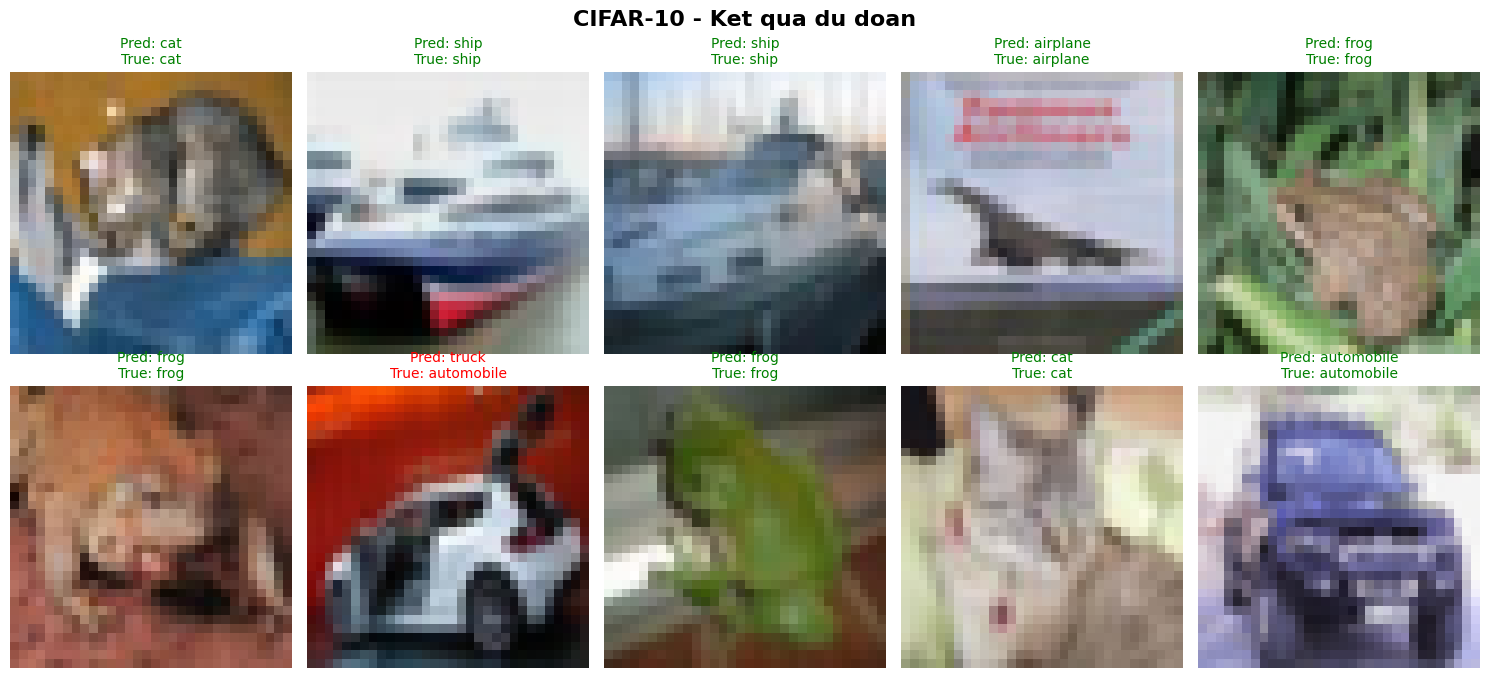

In [35]:
# Predictions and display CIFAR-10 results
cifar_model.eval()
test_images = torch.from_numpy(x_test_cifar[:10]).float().to(device)

with torch.no_grad():
    predictions = cifar_model(test_images)
    predictions = torch.nn.functional.softmax(predictions, dim=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i, ax in enumerate(axes.flat):
    img = x_test_cifar[i].transpose(1, 2, 0)
    ax.imshow(img)
    pred_label = class_names[torch.argmax(predictions[i]).item()]
    true_label = class_names[y_test_cifar[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    ax.axis('off')
plt.suptitle("CIFAR-10 - Ket qua du doan", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phần C: Visualize các tham số, số lượng layer, số lượng tham số huấn luyện
### 1. Trích xuất thông tin chi tiết từng layer

In [36]:
# Extract detailed layer information
def get_model_info(model, model_name):
    info = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear, nn.BatchNorm2d, nn.BatchNorm1d)):
            params = sum(p.numel() for p in module.parameters())
            trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
            info.append({
                'Layer Name': name,
                'Layer Type': module.__class__.__name__,
                'Total Params': params,
                'Trainable': trainable,
                'Non-Trainable': params - trainable,
            })
    return pd.DataFrame(info)

print("=" * 70)
print("MNIST MODEL - Chi tiet tung layer")
print("=" * 70)
mnist_info = get_model_info(mnist_model, 'MNIST')
display(mnist_info)

print(f"\n{'='*70}")
print("CIFAR-10 MODEL - Chi tiet tung layer")
print("=" * 70)
cifar_info = get_model_info(cifar_model, 'CIFAR-10')
display(cifar_info)

MNIST MODEL - Chi tiet tung layer


,Layer Name,Layer Type,Total Params,Trainable,Non-Trainable
0,conv1,Conv2d,320,320,0
1,bn1,BatchNorm2d,64,64,0
2,conv2,Conv2d,18496,18496,0
3,bn2,BatchNorm2d,128,128,0
4,conv3,Conv2d,36928,36928,0
5,bn3,BatchNorm2d,128,128,0
6,fc1,Linear,401536,401536,0
7,fc2,Linear,1290,1290,0



CIFAR-10 MODEL - Chi tiet tung layer


,Layer Name,Layer Type,Total Params,Trainable,Non-Trainable
0,conv1,Conv2d,896,896,0
1,bn1,BatchNorm2d,64,64,0
2,conv2,Conv2d,9248,9248,0
3,bn2,BatchNorm2d,64,64,0
4,conv3,Conv2d,18496,18496,0
5,bn3,BatchNorm2d,128,128,0
6,conv4,Conv2d,36928,36928,0
7,bn4,BatchNorm2d,128,128,0
8,conv5,Conv2d,73856,73856,0
9,bn5,BatchNorm2d,256,256,0


### 2. Biểu đồ số tham số từng layer

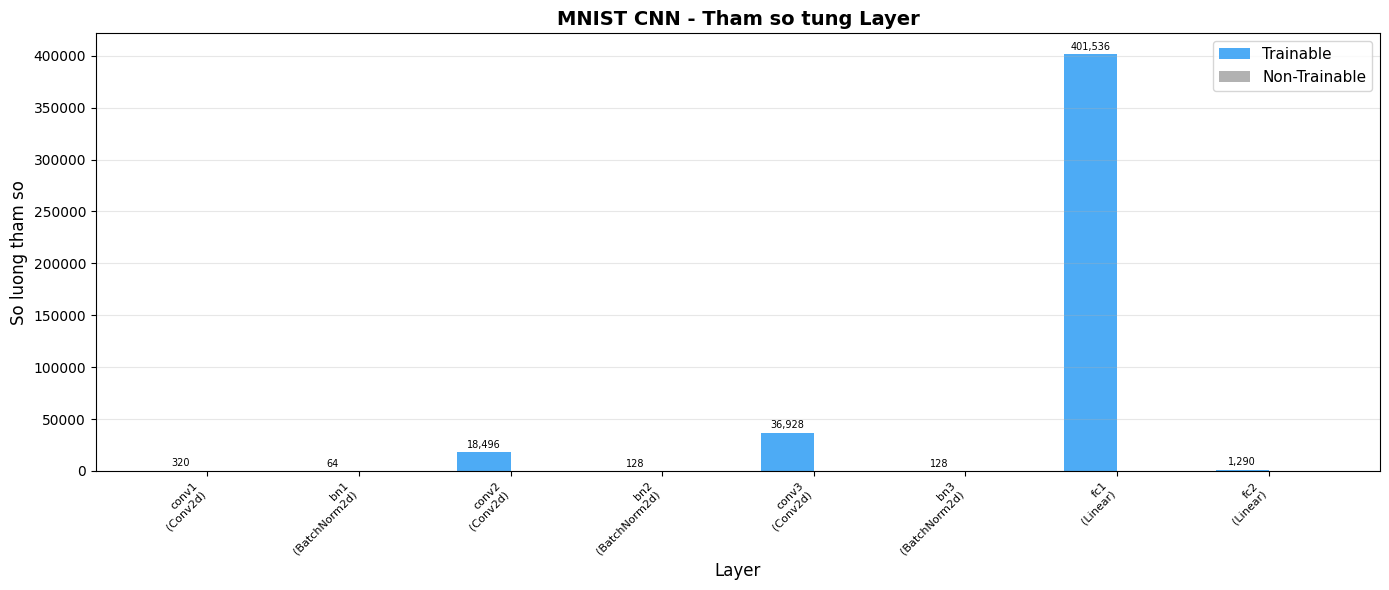

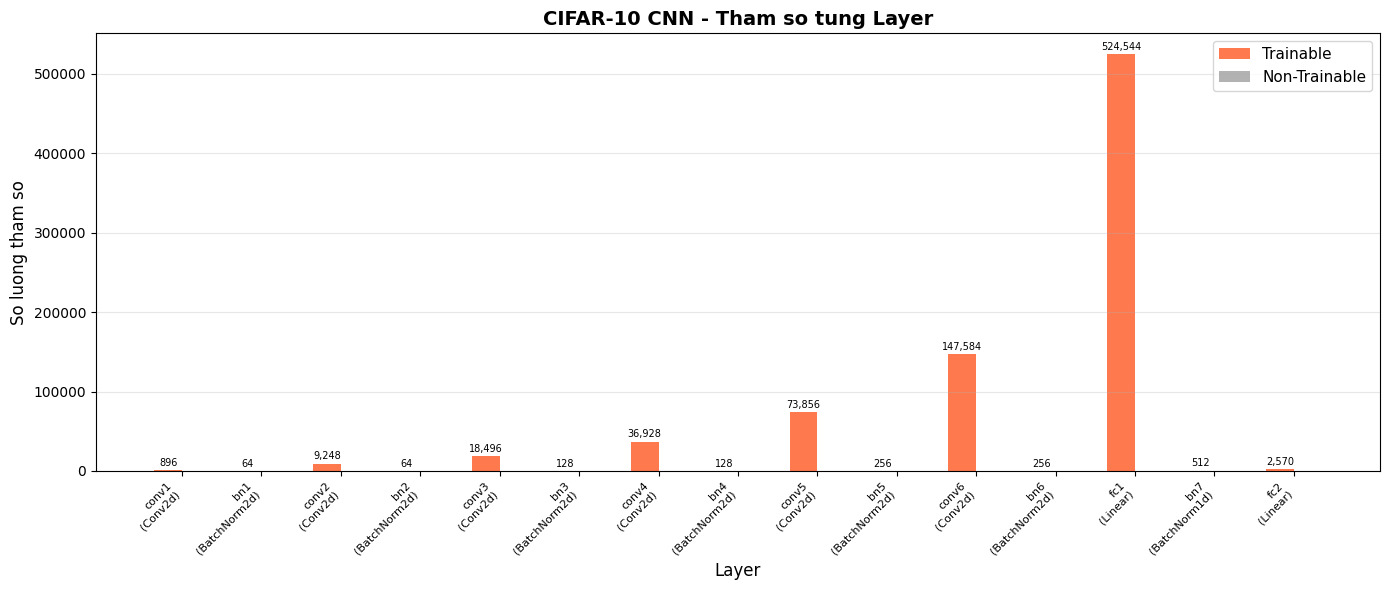

In [37]:
# Plot layer parameters
def plot_layer_params(model, model_name, color):
    layer_names = []
    trainable_params = []
    non_trainable_params = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear, nn.BatchNorm2d, nn.BatchNorm1d)):
            params = sum(p.numel() for p in module.parameters())
            if params > 0:
                trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
                layer_names.append(f"{name.split('.')[-1]}\n({module.__class__.__name__})")
                trainable_params.append(trainable)
                non_trainable_params.append(params - trainable)

    x = np.arange(len(layer_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    bars1 = ax.bar(x - width/2, trainable_params, width, label='Trainable', color=color, alpha=0.8)
    bars2 = ax.bar(x + width/2, non_trainable_params, width, label='Non-Trainable', color='gray', alpha=0.6)

    ax.set_xlabel('Layer', fontsize=12)
    ax.set_ylabel('So luong tham so', fontsize=12)
    ax.set_title(f'{model_name} - Tham so tung Layer', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(layer_names, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    for bar in bars1:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{int(height):,}', xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7)
    plt.tight_layout()
    plt.show()

plot_layer_params(mnist_model, 'MNIST CNN', '#2196F3')
plot_layer_params(cifar_model, 'CIFAR-10 CNN', '#FF5722')

### 3. So sánh tổng quan 2 mô hình

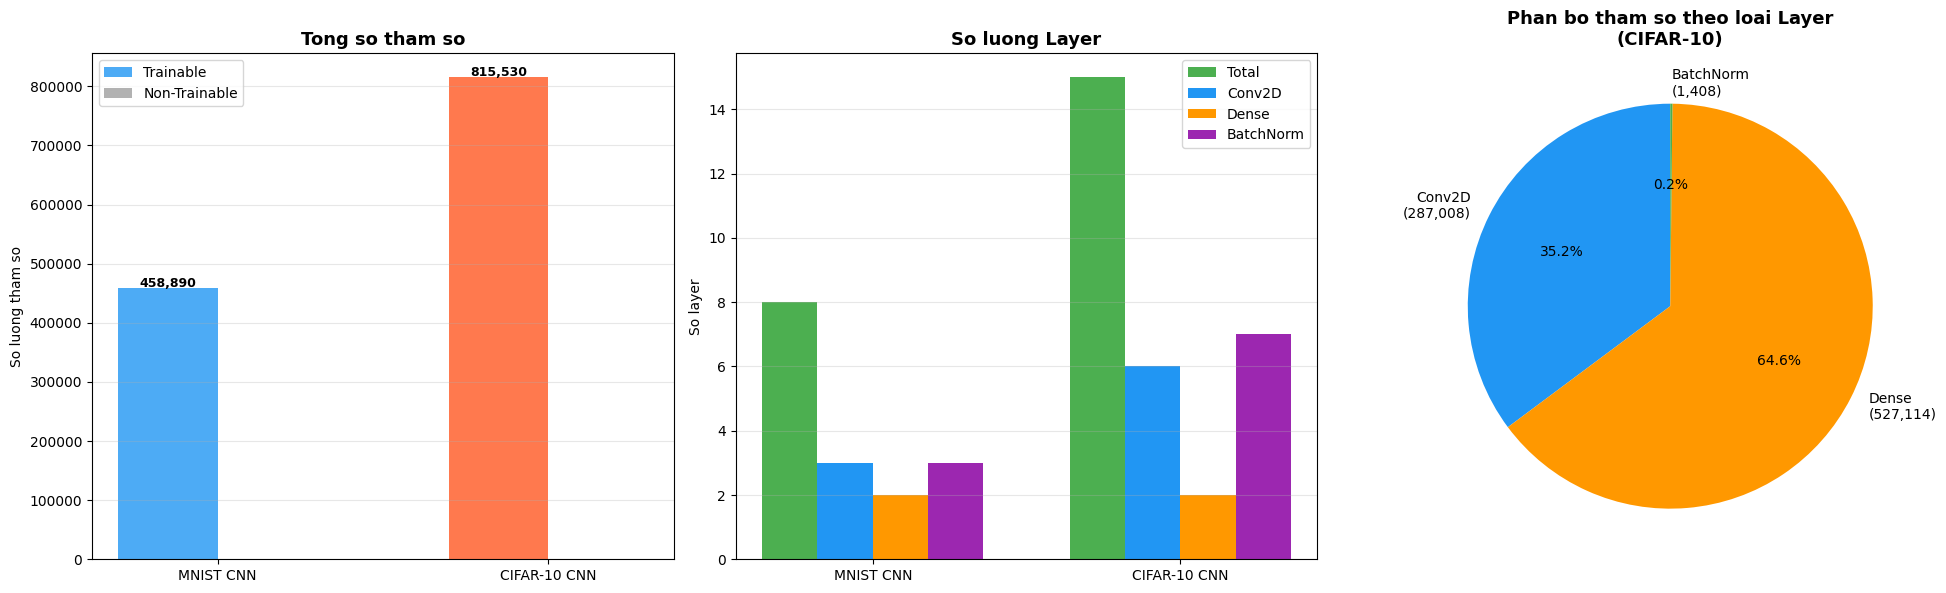

In [38]:
# Model comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

model_names = ['MNIST CNN', 'CIFAR-10 CNN']
all_models = [mnist_model, cifar_model]
colors = ['#2196F3', '#FF5722']

# Count trainable and non-trainable parameters
trainable = [sum(p.numel() for p in m.parameters() if p.requires_grad) for m in all_models]
non_trainable = [sum(p.numel() for p in m.parameters() if not p.requires_grad) for m in all_models]

x = np.arange(2)
width = 0.3
axes[0].bar(x - width/2, trainable, width, label='Trainable', color=colors, alpha=0.8)
axes[0].bar(x + width/2, non_trainable, width, label='Non-Trainable', color='gray', alpha=0.6)
axes[0].set_title('Tong so tham so', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].set_ylabel('So luong tham so')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, t in enumerate(trainable):
    axes[0].text(i - width/2, t + 2000, f'{t:,}', ha='center', fontsize=9, fontweight='bold')

# Count layers by type
def count_layers(model):
    conv_count = sum(1 for m in model.modules() if isinstance(m, nn.Conv2d))
    dense_count = sum(1 for m in model.modules() if isinstance(m, nn.Linear))
    bn_count = sum(1 for m in model.modules() if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)))
    return conv_count + dense_count + bn_count, conv_count, dense_count, bn_count

total_layers = [count_layers(m)[0] for m in all_models]
conv_layers = [count_layers(m)[1] for m in all_models]
dense_layers = [count_layers(m)[2] for m in all_models]
bn_layers = [count_layers(m)[3] for m in all_models]

width = 0.18
axes[1].bar(x - 1.5*width, total_layers, width, label='Total', color='#4CAF50')
axes[1].bar(x - 0.5*width, conv_layers, width, label='Conv2D', color='#2196F3')
axes[1].bar(x + 0.5*width, dense_layers, width, label='Dense', color='#FF9800')
axes[1].bar(x + 1.5*width, bn_layers, width, label='BatchNorm', color='#9C27B0')
axes[1].set_title('So luong Layer', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_ylabel('So layer')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Parameter distribution for CIFAR-10
conv_params = sum(p.numel() for m in cifar_model.modules() if isinstance(m, nn.Conv2d) for p in m.parameters())
dense_params = sum(p.numel() for m in cifar_model.modules() if isinstance(m, nn.Linear) for p in m.parameters())
bn_params = sum(p.numel() for m in cifar_model.modules() if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)) for p in m.parameters())

sizes = [conv_params, dense_params, bn_params]
labels_pie = [f'Conv2D\n({conv_params:,})', f'Dense\n({dense_params:,})', f'BatchNorm\n({bn_params:,})']
pie_colors = ['#2196F3', '#FF9800', '#4CAF50']

axes[2].pie(sizes, labels=labels_pie, autopct='%1.1f%%', startangle=90,
            colors=pie_colors, textprops={'fontsize': 10})
axes[2].set_title('Phan bo tham so theo loai Layer\n(CIFAR-10)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 4. Bảng tổng hợp so sánh

In [39]:
# Comparison table
def count_layers_by_type(model):
    conv_count = sum(1 for m in model.modules() if isinstance(m, nn.Conv2d))
    dense_count = sum(1 for m in model.modules() if isinstance(m, nn.Linear))
    bn_count = sum(1 for m in model.modules() if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)))
    dropout_count = sum(1 for m in model.modules() if isinstance(m, nn.Dropout))
    return conv_count, dense_count, bn_count, dropout_count

mnist_conv, mnist_dense, mnist_bn, mnist_drop = count_layers_by_type(mnist_model)
cifar_conv, cifar_dense, cifar_bn, cifar_drop = count_layers_by_type(cifar_model)

comparison = pd.DataFrame({
    'Metric': [
        'Input Shape',
        'Total Layers',
        'Conv2D Layers',
        'Dense Layers',
        'BatchNorm Layers',
        'Dropout Layers',
        'Total Parameters',
        'Trainable Parameters',
        'Non-Trainable Parameters',
        'Data Augmentation',
        'Epochs',
        'Batch Size'
    ],
    'MNIST CNN': [
        '(1, 28, 28)',
        count_layers(mnist_model)[0],
        mnist_conv,
        mnist_dense,
        mnist_bn,
        mnist_drop,
        f"{sum(p.numel() for p in mnist_model.parameters()):,}",
        f"{sum(p.numel() for p in mnist_model.parameters() if p.requires_grad):,}",
        f"{sum(p.numel() for p in mnist_model.parameters() if not p.requires_grad):,}",
        'Khong',
        10,
        128
    ],
    'CIFAR-10 CNN': [
        '(3, 32, 32)',
        count_layers(cifar_model)[0],
        cifar_conv,
        cifar_dense,
        cifar_bn,
        cifar_drop,
        f"{sum(p.numel() for p in cifar_model.parameters()):,}",
        f"{sum(p.numel() for p in cifar_model.parameters() if p.requires_grad):,}",
        f"{sum(p.numel() for p in cifar_model.parameters() if not p.requires_grad):,}",
        'Co (Flip, Rotate)',
        30,
        64
    ]
})

display(comparison)

,Metric,MNIST CNN,CIFAR-10 CNN
0,Input Shape,"(1, 28, 28)","(3, 32, 32)"
1,Total Layers,8,15
2,Conv2D Layers,3,6
3,Dense Layers,2,2
4,BatchNorm Layers,3,7
5,Dropout Layers,1,4
6,Total Parameters,"458,890","815,530"
7,Trainable Parameters,"458,890","815,530"
8,Non-Trainable Parameters,0,0
9,Data Augmentation,Khong,"Co (Flip, Rotate)"


---
## Kết luận

| | MNIST | CIFAR-10 |
|---|---|---|
| **Độ khó** | Dễ (grayscale, đơn giản) | Khó hơn (RGB, phức tạp) |
| **Mô hình** | 3 Conv + 2 Dense | 6 Conv + 2 Dense + Augmentation |
| **Accuracy** | ~99% | ~85-90% |
| **Nhận xét** | CNN cơ bản đã đủ tốt | Cần mô hình sâu hơn + augmentation |